In [1]:
import xarray as xr
import glob
import os
import tqdm

In [2]:
# Import monthly and annual average net shortwave radiation (qsr) from ouputs from shortwave_radiation.py

ds_monthly_runs = {}
ds_annual_runs = {}

runs_config = [
    {
        'name': 'OWB',
        'idir': '/gws/pw/j25/rep/omerrett/OWB/Analysis/qsr'
    },
    {
        'name': 'AOWB',
        'idir': '/gws/pw/j25/rep/omerrett/AOWB_RALP3P3_fixes/Analysis/qsr'
    }
]

# This gives a useful format for calculating seasonal averages
for run in runs_config:
    print(f"--- Aggregating Run: {run['name']} ---")
    
    ds_monthly = xr.open_dataset(f"{run['idir']}/qsr_monthly_means_2018.nc")
    ds_monthly_runs[run['name']] = ds_monthly
    ds_annual = xr.open_dataset(f"{run['idir']}/qsr_annual_means_2018.nc")
    ds_annual_runs[run['name']] = ds_annual



print("\nAll aggregations completed! Your monthly data is ready in `ds_monthly_runs`.")

--- Aggregating Run: OWB ---
--- Aggregating Run: AOWB ---

All aggregations completed! Your monthly data is ready in `ds_monthly_runs`.


In [3]:
# Calculate differences in average qsr between models and assign these lat and lon

qsr_diff = ds_monthly_runs['AOWB']['qsr'] - ds_monthly_runs['OWB']['qsr']
qsr_diff_annual = ds_annual_runs['AOWB']['qsr'] - ds_annual_runs['OWB']['qsr']

qsr_diff = qsr_diff.assign_coords({"nav_lon": ds_monthly_runs['AOWB'].nav_lon, "nav_lat": ds_monthly_runs['AOWB'].nav_lat})
qsr_diff_annual = qsr_diff_annual.assign_coords({"nav_lon": ds_monthly_runs['AOWB'].nav_lon, "nav_lat": ds_monthly_runs['AOWB'].nav_lat})


In [4]:
# Calculate seasonal averages

seasons = ['JF', 'MAM', 'JJA', 'SON']
season_indices = {
    'JF': [0, 1],
    'MAM': [2, 3, 4],
    'JJA': [5, 6, 7],
    'SON': [8, 9, 10]
}

qsr_seasonal = {}

for s in seasons:
    idxs = season_indices[s]
    qsr_seasonal[s] = qsr_diff.isel(time_counter=idxs).mean(dim='time_counter', keep_attrs=True)

In [5]:
# Add annual averages to the data that will be plotted

qsr_data = qsr_seasonal

qsr_data['Annual'] = qsr_diff_annual

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.pyplot as plt

# Use the same plotting style throughout all plots
plt.style.use('seaborn-v0_8-whitegrid')

# Define the tight extent for the AMM15 region
TIGHT_EXTENT = [-18.5, 8, 44, 63] 

# Define the Lambert Conformal Conic (LCC) projection for a spherical look
NORTH_SEA_PROJECTION = ccrs.LambertConformal(
    central_longitude=-5,
    central_latitude=50.0,
    standard_parallels=(50.0, 60.0)
)

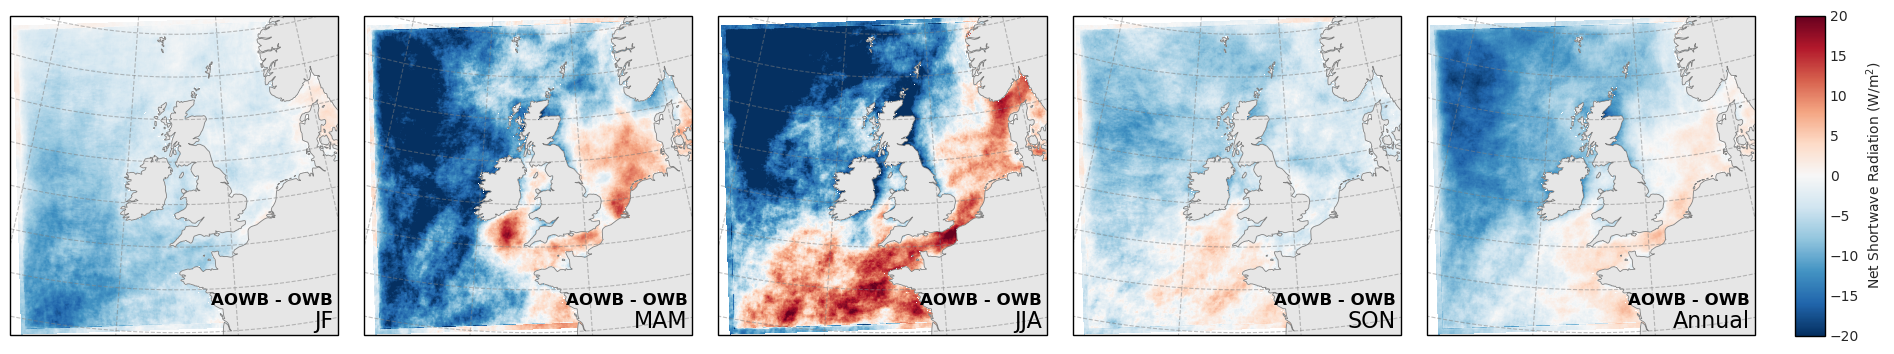

In [7]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=5, 
    figsize=(20, 4),  
    subplot_kw={'projection': NORTH_SEA_PROJECTION}
)

p_qsr = None

seasons_to_plot = ['JF', 'MAM', 'JJA', 'SON', 'Annual']

for idx, s in enumerate(seasons_to_plot):
    
    ax_qsr = axes[idx]
    ax_qsr.add_feature(cfeature.LAND, facecolor='#E6E6E6', zorder=1)
    
    p_qsr = qsr_seasonal[s].plot(
        ax=ax_qsr,
        x= 'nav_lon',
        y='nav_lat',
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=-20, vmax=20,
        add_colorbar=False,
        zorder=2
    )
    
    ax_qsr.set_extent(TIGHT_EXTENT, crs=ccrs.PlateCarree())
    ax_qsr.coastlines(resolution='50m', linewidth=0.6, color='grey', zorder=3)
    ax_qsr.gridlines(draw_labels=False, color='grey', linestyle='--', alpha=0.5)
    ax_qsr.set_title('')
    ax_qsr.set_xlabel(''); ax_qsr.set_ylabel('')
    
    
    ax_qsr.text(
        0.985, 0.085, 
        'AOWB - OWB',
        transform=ax_qsr.transAxes, 
        fontsize=12, 
        fontweight='bold',
        color='black',
        ha='right',
        va = 'bottom',
        zorder=6
        ) 

    # Adds seasonal titles onto plot
    ax_qsr.text(
        0.985, 0.08, 
        s,
        transform=ax_qsr.transAxes, 
        fontsize=16, 
        color='black',
        ha='right',
        va= 'top',
        zorder=6
        )
    
    for spine in ax_qsr.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)
        
plt.tight_layout()
fig.subplots_adjust(right=0.88, hspace=0.12, wspace=0.08)

cbar_ax_qsr = fig.add_axes([0.90, 0.1, 0.015, 0.8])
cbar_qsr = fig.colorbar(p_qsr, cax=cbar_ax_qsr, label=r'Net Shortwave Radiation (W/m$^2$)')
cbar_qsr.outline.set_edgecolor('black')
cbar_qsr.outline.set_linewidth(1)

plt.savefig('qsr_seasonal_differences.png', dpi=600, bbox_inches='tight')
plt.show()